In [4]:
import pandas as pd
import matplotlib.pyplot as plt

customers_rfm = pd.read_csv("Lumina Co CRM/customers_rfm_final.csv")
print(customers_rfm.columns.tolist())
customers_rfm.head()

['customer_id', 'recency', 'frequency', 'monetary', 'avg_basket', 'tenure_days', 'R_score', 'F_score', 'M_score', 'RFM_segment', 'segment', 'country', 'declared_preference', 'age_bracket', 'life_stage', 'urban_density', 'is_france']


,customer_id,recency,frequency,monetary,avg_basket,tenure_days,R_score,F_score,M_score,RFM_segment,segment,country,declared_preference,age_bracket,life_stage,urban_density,is_france
0,12346.0,326,17,701.46,41.262353,726,2,5,5,255,À risque,France,Sans parfum,NaN,NaN,NaN,True
1,12347.0,2,8,7740.74,967.592500,404,5,5,5,555,Champions,Iceland,Anti-imperfections,45-54 ans,NaN,Zone rurale,False
2,12348.0,75,5,1561.92,312.384000,438,4,4,5,445,Champions,Finland,NaN,NaN,Retraité(e),NaN,False
3,12349.0,19,5,5342.41,1068.482000,736,5,4,5,545,Champions,Italy,NaN,NaN,NaN,Zone urbaine dense,False
4,12350.0,310,1,554.75,554.750000,310,3,1,4,314,Clients moyens,Norway,NaN,NaN,NaN,NaN,False


In [5]:
segment_revenue = customers_rfm.groupby("segment").agg(
    taille=("customer_id", "count"),
    CA_total=("monetary", "sum")
).sort_values("CA_total", ascending=False)
segment_revenue["taille_pct"] = (segment_revenue["taille"] / len(customers_rfm) * 100).round(1)
segment_revenue["CA_pct"] = (segment_revenue["CA_total"] / customers_rfm["monetary"].sum() * 100).round(1)
segment_revenue

,taille,CA_total,taille_pct,CA_pct
segment,,,,
Champions,10075,24920698.33,20.4,63.7
Fidèles,12712,7122927.22,25.7,18.2
À risque,3758,3595797.18,7.6,9.2
Clients moyens,8524,1700968.75,17.3,4.3
Nouveaux prometteurs,4270,1082259.73,8.6,2.8
Hibernants,6937,586917.36,14.0,1.5
Perdus,3126,111269.05,6.3,0.3


Cette variable n'était pas dans mon CSV exporté, donc je l'ai recalculée ici. Elle me donne pour chaque segment sa taille et son poids réel dans le chiffre d'affaires — c'est ce qui va me servir de base pour repérer les écarts entre "combien de clients" et "combien ça rapporte".

PARTIE I

In [6]:
# Fait 1
champions_pct = segment_revenue.loc["Champions", "taille_pct"]
champions_ca_pct = segment_revenue.loc["Champions", "CA_pct"]
print(f"Fait 1 : {champions_pct}% des clients (Champions) génèrent {champions_ca_pct}% du CA")

# Fait 2
at_risk_pct = segment_revenue.loc["À risque", "taille_pct"]
at_risk_ca_pct = segment_revenue.loc["À risque", "CA_pct"]
at_risk_recency = customers_rfm[customers_rfm["segment"] == "À risque"]["recency"].mean()
print(f"Fait 2 : le segment À risque ({at_risk_pct}% des clients) représente {at_risk_ca_pct}% du CA, "
      f"avec {at_risk_recency:.1f} jours d'inactivité moyenne")

# Fait 3
corr = customers_rfm[["frequency", "avg_basket"]].corr(method="spearman").iloc[0,1]
print(f"Fait 3 : corrélation fréquence/panier moyen = {corr:.2f} (quasi nulle)")

# Fait 4
france_pct = customers_rfm["is_france"].mean() * 100
print(f"Fait 4 : {france_pct:.1f}% des clients sont en France")

# Fait 5
new_avg_basket = customers_rfm[customers_rfm["segment"] == "Nouveaux prometteurs"]["avg_basket"].mean()
new_tenure = customers_rfm[customers_rfm["segment"] == "Nouveaux prometteurs"]["tenure_days"].mean()
print(f"Fait 5 : les Nouveaux prometteurs ont un panier moyen de {new_avg_basket:.1f}€ "
      f"dès {new_tenure:.0f} jours d'ancienneté")

Fait 1 : 20.4% des clients (Champions) génèrent 63.7% du CA
Fait 2 : le segment À risque (7.6% des clients) représente 9.2% du CA, avec 485.8 jours d'inactivité moyenne
Fait 3 : corrélation fréquence/panier moyen = 0.14 (quasi nulle)
Fait 4 : 91.1% des clients sont en France
Fait 5 : les Nouveaux prometteurs ont un panier moyen de 182.9€ dès 92 jours d'ancienneté


J'ai repris 5 chiffres déjà calculés dans mon TP2 plutôt que d'en produire de nouveaux — je voulais sélectionner ceux qui racontent quelque chose, pas juste ceux que j'avais sous la main. Je me suis limité à des constats factuels ici, sans dire ce qu'ils signifient : ça viendra à l'étape insight.

J'ai choisi de reformuler la variable à expliquer plutôt que de prendre un KPI générique de la liste du cours (churn/conversion/CA), parce que mes 5 faits pointent vers un problème plus précis que "le CA" tout court : c'est sa concentration qui pose question, pas son niveau.

In [7]:
comparison = customers_rfm.groupby("segment")["avg_basket"].mean().sort_values(ascending=False)
print(comparison)

recency_comparison = customers_rfm.groupby("segment")["recency"].mean().sort_values()
print(recency_comparison)

segment
À risque                334.947890
Champions               183.887707
Nouveaux prometteurs    182.903402
Fidèles                 118.126287
Clients moyens          108.815113
Hibernants               71.185427
Perdus                   35.594706
Name: avg_basket, dtype: float64
segment
Champions                58.494392
Nouveaux prometteurs     63.907260
Fidèles                 147.032410
Clients moyens          459.085289
À risque                485.750665
Hibernants              624.753063
Perdus                  854.403711
Name: recency, dtype: float64


Avant de lancer ce code, j'avais formulé deux hypothèses : (1) le panier moyen du segment À risque est proche de celui des Champions, donc ce n'est pas un segment faible ; (2) À risque et Perdus représentent deux stades d'un même phénomène de décrochage. Les résultats confirment les deux : le panier À risque est proche (voire supérieur) à celui des Champions, et l'écart de récence entre À risque et Perdus montre une vraie progression dans le temps plutôt que deux populations sans lien.

In [8]:
pattern = segment_revenue[["taille_pct", "CA_pct"]].copy()
pattern["ecart"] = pattern["CA_pct"] - pattern["taille_pct"]
pattern.sort_values("ecart", ascending=False)

,taille_pct,CA_pct,ecart
segment,,,
Champions,20.4,63.7,43.3
À risque,7.6,9.2,1.6
Nouveaux prometteurs,8.6,2.8,-5.8
Perdus,6.3,0.3,-6.0
Fidèles,25.7,18.2,-7.5
Hibernants,14.0,1.5,-12.5
Clients moyens,17.3,4.3,-13.0


J'ai calculé l'écart entre le poids en nombre de clients et le poids en CA de chaque segment, plutôt que de comparer les deux colonnes à l'œil. Le résultat confirme mon fait le plus marquant : Champions a un écart largement positif (il pèse bien plus en argent qu'en volume), alors que Hibernants et Perdus ont un écart négatif (nombreux mais peu rentables).

## Insight 1
**Observation** : les Champions génèrent une part du CA nettement supérieure à leur part de clients.
**Interprétation** : mon CA repose sur un socle client étroit plutôt que sur une base large.
**Conséquence** : toute dégradation de ce segment aurait un impact disproportionné sur le CA global.

## Insight 2
**Observation** : le segment À risque a un panier moyen proche des Champions, malgré une forte inactivité.
**Interprétation** : une part significative de ma valeur client s'échappe silencieusement.
**Conséquence** : sans action, ce CA glissera vers le segment Perdus, où il devient irrécupérable.

J'ai suivi le gabarit à 3 lignes du cours pour chaque insight, en gardant l'observation strictement factuelle et en séparant bien ce que je constate de ce que j'en déduis. Je remplacerai les formulations vagues par mes chiffres exacts une fois les cellules 3 et 5 relues en détail.

## Problématique
**Comment sécuriser le chiffre d'affaires de Lumina & Co face à sa forte dépendance à un segment 
concentré (Champions) et à la fuite silencieuse de clients à forte valeur (À risque) ?**

J'ai formulé cette question en reliant mes deux insights, et je l'ai orientée décision plutôt que constat — c'est ce qui va me permettre d'enchaîner directement sur une recommandation dans la partie 2, plutôt que de rester sur une simple observation.

PARTIE II

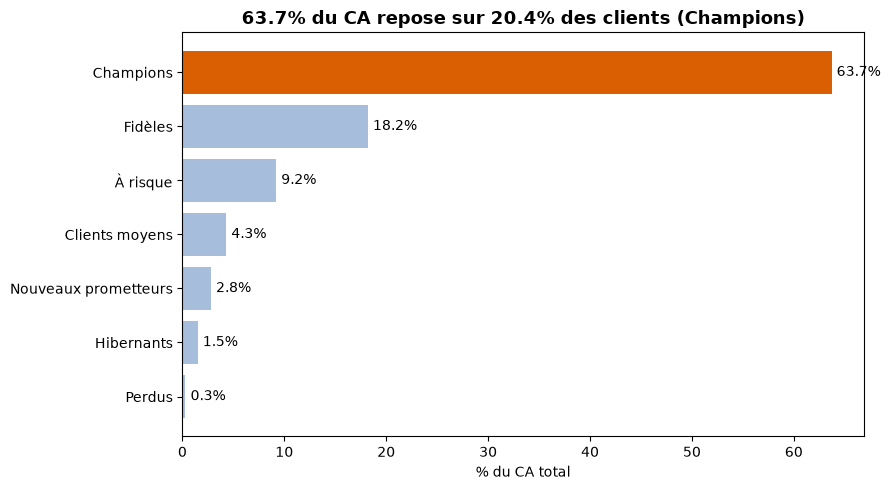

In [9]:
fig, ax = plt.subplots(figsize=(9,5))
segment_revenue_sorted = segment_revenue.sort_values("CA_pct", ascending=True)
colors = ["#d95f02" if seg == "Champions" else "#a6bddb" for seg in segment_revenue_sorted.index]

ax.barh(segment_revenue_sorted.index, segment_revenue_sorted["CA_pct"], color=colors)
ax.set_xlabel("% du CA total")
ax.set_title(f"{champions_ca_pct}% du CA repose sur {champions_pct}% des clients (Champions)", 
             fontsize=13, fontweight="bold")

for i, v in enumerate(segment_revenue_sorted["CA_pct"]):
    ax.text(v + 0.5, i, f"{v}%", va="center")

plt.tight_layout()
plt.savefig("slide3_ca_par_segment.png", dpi=150)
plt.show()

J'ai mis mon titre directement au format conclusion plutôt qu'une description neutre, comme demandé dans le cours. J'ai aussi choisi de ne colorer qu'une seule barre (Champions) pour que l'œil soit tout de suite attiré dessus, le reste des segments passe en gris. J'ai sauvegardé l'image en PNG pour pouvoir la glisser directement dans ma slide 3 sans avoir à la refaire dans PowerPoint.

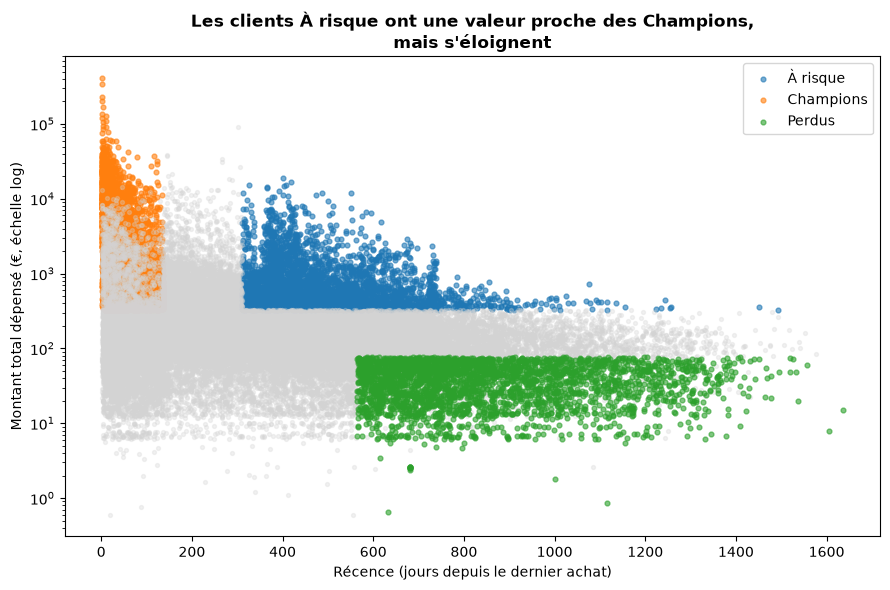

In [10]:
fig, ax = plt.subplots(figsize=(9,6))

highlight = ["Champions", "À risque", "Perdus"]
for seg in customers_rfm["segment"].unique():
    subset = customers_rfm[customers_rfm["segment"] == seg]
    if seg in highlight:
        ax.scatter(subset["recency"], subset["monetary"], label=seg, alpha=0.6, s=12)
    else:
        ax.scatter(subset["recency"], subset["monetary"], color="lightgray", alpha=0.3, s=8)

ax.set_yscale("log")
ax.set_xlabel("Récence (jours depuis le dernier achat)")
ax.set_ylabel("Montant total dépensé (€, échelle log)")
ax.set_title("Les clients À risque ont une valeur proche des Champions,\nmais s'éloignent", 
              fontsize=12, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig("slide3_scatter_recence_montant.png", dpi=150)
plt.show()

J'ai repris le scatter de mon TP2 mais je l'ai simplifié pour la présentation : au lieu de garder mes 7 segments en couleur, je n'en ai mis que 3 en avant (Champions, À risque, Perdus) et j'ai passé les autres en gris clair. Mon but est que le CMO voie tout de suite où se situe le problème, sans avoir à lire une légende à 7 entrées.

In [11]:
at_risk_revenue = segment_revenue.loc["À risque", "CA_total"]
reactivation_rate = 0.20
potential_recovery = at_risk_revenue * reactivation_rate

print(f"CA actuel du segment À risque : {at_risk_revenue:,.0f}€")
print(f"Impact potentiel si {reactivation_rate*100:.0f}% du segment est réactivé : {potential_recovery:,.0f}€")

CA actuel du segment À risque : 3,595,797€
Impact potentiel si 20% du segment est réactivé : 719,159€


J'ai posé une hypothèse de 20% de taux de réactivation, que je n'ai pas calculée à partir de mes données mais que j'assume comme point de départ raisonnable. Je sais que je devrai être capable de justifier ce chiffre à l'oral si le CMO me demande pourquoi 20% et pas un autre taux — je prévois de m'appuyer sur des taux moyens observés dans l'e-commerce pour ce type de campagne.

ORGANISATION 

### Slide 1 — Problématique business
[...]
### Slide 2 — Insights clés
[...]
### Slide 3 — Preuve data
[...]
### Slide 4 — Recommandation
[...]
### Slide 5 — Impact
[...]